# Exercise 1 - Smoothing and Interpolation

## Introduction
This exercise is about smoothing and interpolating medical images using B-spline basis functions. First, you will implement the principle on a one-dimensional signal, and then expand it to an image in 2D.

### Instructions for your report
Your report should be structured as follows:
* **Introduction**: a short summary of what your report is about, perhaps with a recap of some of the equations you'll be using in your solution.
* **Task 1, ..., 5**: for each specific task listed below, your code (in code cells), your results (as figures) as well as explanations of what is computed and what is shown in the figures (in Markdown cells). 
* **Conclusion**: a short summary of your findings.

This introduction should **not** be part of your report.

### Input data and code hints
Import Python libraries

In [78]:
import numpy as np
import nibabel as nib
from matplotlib import pyplot as plt

np.set_printoptions( suppress=True )
plt.style.use('dark_background') # Dark theme
plt.ion()

Read a 3D image (an MRI scan of the brain) and extract the 2D slice you'll be working with in this exercise:

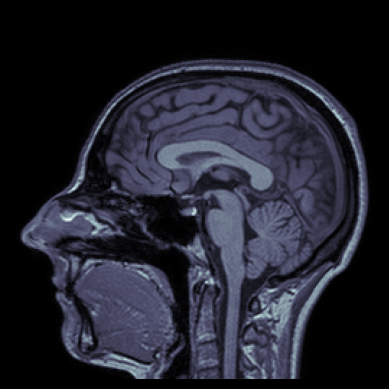

In [79]:
T1_file = './IXI002-Guys-0828-T1.nii.gz'
T1_nib = nib.load( T1_file )
data = T1_nib.get_fdata()

img = data[:, :, 75]
T = np.flipud( img.T )

plt.axis('off')
plt.imshow(T, cmap='bone');

Extract the 1D signal you'll be working with as the middle row of the 2D image

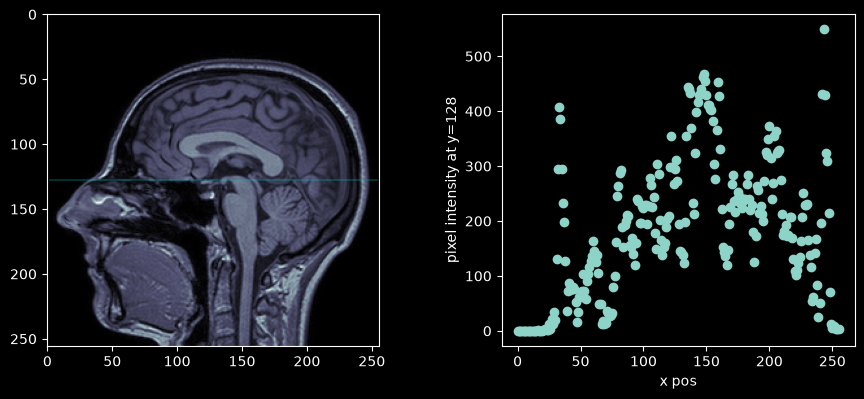

In [80]:
row = round( T.shape[0] / 2 )
t = T[row, :] #pixel intensity at row y = 128

N = t.shape[0]
x = np.arange(0, N)

# plot
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(10,5))
fig.tight_layout(pad=5.0)

ax[0].imshow(T, cmap='bone')
ax[0].hlines(row, xmin=1, xmax=255, alpha=0.25, color='c')

ax[1].scatter(x, t)
ax[1].set_xlabel('x pos')
ax[1].set_ylabel('pixel intensity at y={}'.format(row))

plt.show();

---
## Task 1: B-splines basis functions
Implement a function that evaluates the uniform B-spline of orders 0, 1 and 3 at the locations provided in a vector $\mathbf{x}$. 

The function should return a vector $\mathbf{y}$ that is the same length as $\mathbf{x}$:

    def eval_BSpline(x, order=0):

        """
        Evaluates the uniform B-spline of order "order" at the locations in vector "x"
        """

        ...

        return y


Use this function to plot the uniform B-spline of orders 0, 1 and 3 at locations:  $\mathbf{x} = [-3.0,-2.99,-2.98, \ldots, 2.99,3.0]$

> ***Hint:*** use the function ```np.arange()``` to obtain $\mathbf{x}$. Although the different order b-splines can be implemented using convolutions, it's easier to use the analytical expressions in the book.

In [81]:
from scipy.interpolate import BSpline

def eval_BSpline(x, order=0):
    """
    Evaluates the uniform B-spline of order "order" at the locations in vector "x"
    """
    p = order
    t = np.arange(p + 2) - (p + 1) / 2.0  
    spline = BSpline.basis_element(t, extrapolate=False)

    y = spline(x)
    y = np.nan_to_num(y)  # outside support -> 0 instead of NaN

    return y

In [82]:
def eval_BSpline(x, order=0):
    """
    Evaluates the uniform B-spline of order "order" at the locations in vector "x"
    """

    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)

    if order == 0:
        y[np.abs(x) < 0.5] = 1
        y[np.abs(x) == 0.5] = 0.5

    elif order == 1:
        position = np.abs(x) < 1
        y[position] = 1 - np.abs(x[position])

    elif order == 3:
        position1 = np.abs(x) < 1
        position2 = (1 <= np.abs(x)) & (np.abs(x) < 2)
        y[position1] = 2/3 - np.abs(x[position1])**2 +((np.abs(x[position1])**3)/2)
        y[position2] = (2 - np.abs(x[position2]))**3/6
    

    return y

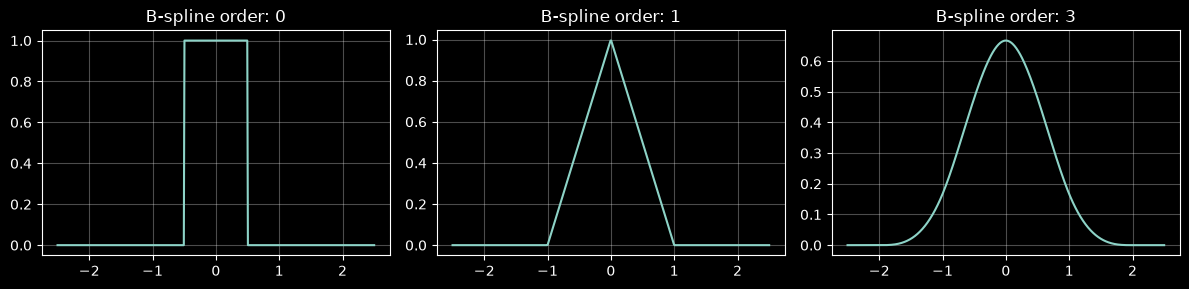

In [83]:
ex = np.linspace(-2.5, 2.5, 500)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, p in zip(axes, [0, 1, 3]):
    y = eval_BSpline(ex, order=p)
    ax.plot(ex, y)
    ax.set_title(f"B-spline order: {p}")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Task 2: Smoothing
Using the function you wrote above for evaluating a uniform B-spline of order 3, generate $M=6$ basis functions covering the entire domain $x=0,1,\ldots, 255$ of the 1D signal $\mathbf{t}$ defined in the introduction (which has length $N=256$). 

The basis functions should be scaled by a factor $h=(N-1)/(M-1)$, and shifted to be $h$ units apart (see book). 

Collect the obtained basis functions in a $N \times M$ matrix $\boldsymbol{\Phi}$, and plot them.

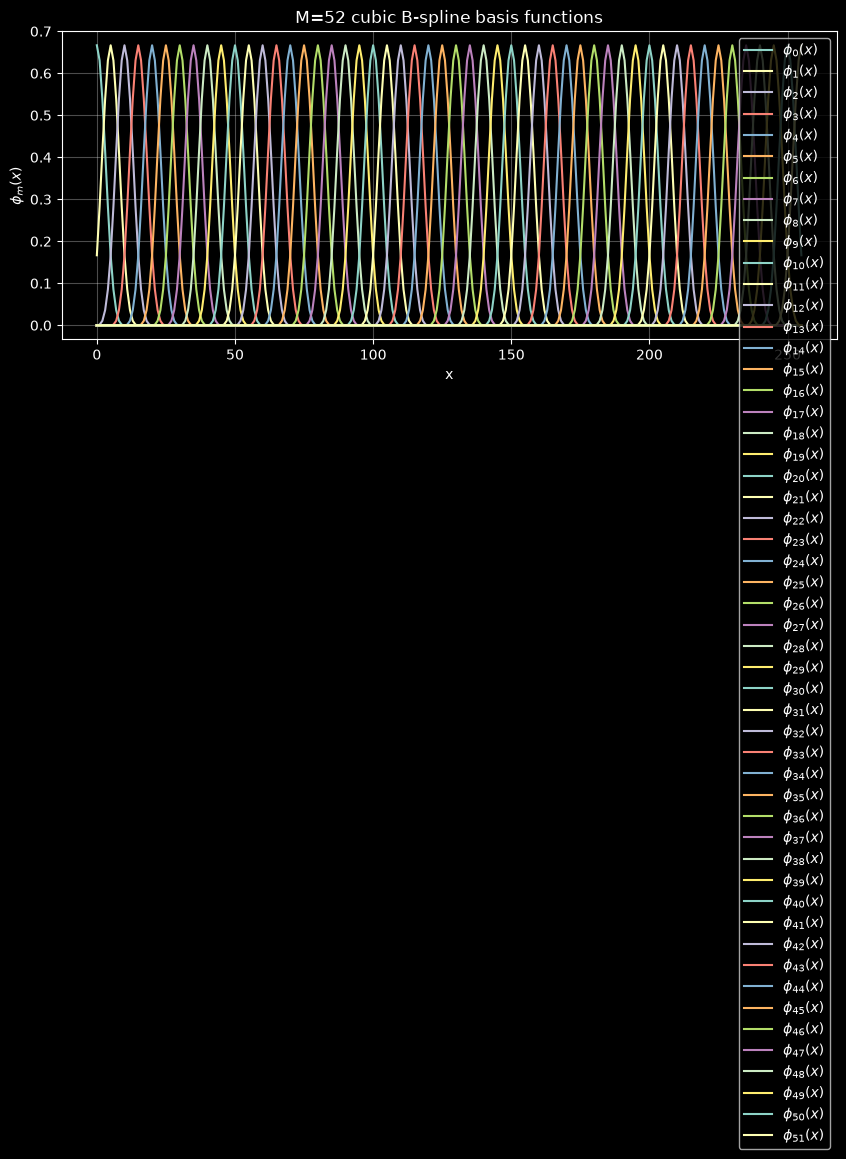

In [88]:
N = 256
M = 52

x = np.arange(0,N)
h = (N - 1) / (M -1)
Phi = np.zeros((N, M))

for m in range(M):
    center = m * h
    Phi[:, m] = eval_BSpline((x - center) / h, order=3)

plt.figure(figsize=(10, 4))
for m in range(M):
    plt.plot(x, Phi[:, m], label=f"$\\phi_{{{m}}}(x)$")
plt.xlabel("x")
plt.ylabel("$\\phi_m(x)$")
plt.title(f"M={M} cubic B-spline basis functions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Compute:
- the smoothing matrix: $\mathbf{S} = \boldsymbol{\Phi} (\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T$
- the smoothed signal:  $\mathbf{\hat{t}} = \mathbf{S} \mathbf{t}$

Plots the results. Also plot the middle row of the smoothing matrix. 

>***Hint:*** 
>
> To compute the solution of a linear equation of the form Ax = b, you can use the following numpy function: ```np.linalg.solve(A, b)```. 
>
> You can also use the matrix inversion function ```np.linalg.inv()```, although this is numerically not the best solution.

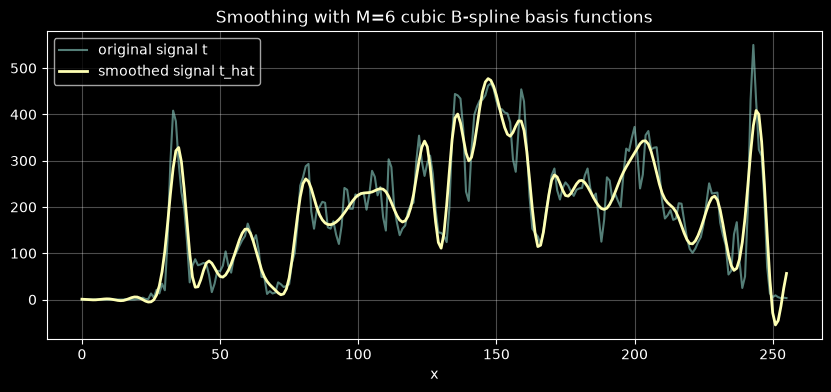

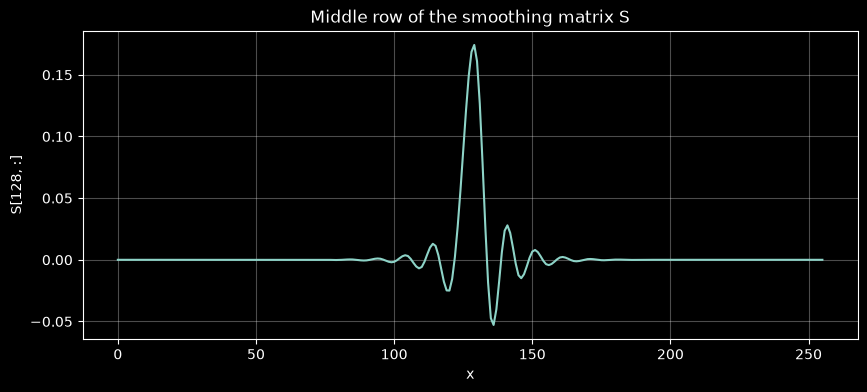

In [89]:
PhiT = Phi.T   
PhiT_Phi = PhiT @ Phi  

Y =  np.linalg.inv(PhiT_Phi)
S = Phi @ Y @ PhiT

t_hat = S @ t

# Plot original vs smoothed signal
plt.figure(figsize=(10, 4))
plt.plot(x, t, label="original signal t", alpha=0.6)
plt.plot(x, t_hat, label="smoothed signal t_hat", linewidth=2)
plt.xlabel("x")
plt.legend()
plt.title("Smoothing with M=6 cubic B-spline basis functions")
plt.grid(alpha=0.3)
plt.show()

# Plot the middle row of the smoothing matrix S
plt.figure(figsize=(10, 4))
middle_row = N // 2
plt.plot(x, S[middle_row, :])
plt.xlabel("x")
plt.ylabel(f"S[{middle_row}, :]")
plt.title("Middle row of the smoothing matrix S")
plt.grid(alpha=0.3)
plt.show()

Now repeat the same experiment when more basis functions are used: $M=16$ and $M=52$. 

> ***Q?:*** How does the smoothing behavior change? Explain.

**A:** As $M$ increases, the basis functions get narrower, so each smoothed point depends on fewer neighbors — less averaging, less smoothing. The fit tracks the data (and its noise) more closely. At $M=N$, $\mathbf{S}$ becomes the identity and there's no smoothing at all — just exact interpolation.

This is visible directly in the middle row of $\mathbf{S}$: it stays bump-shaped but shrinks in width as $M$ grows, since $h=(N-1)/(M-1)$ decreases and shrinks each basis function along with it. So $M$ is really a knob controlling the smoothing–interpolation trade-off: small $M$ gives strong noise suppression at the cost of detail, while $M$ close to $N$ preserves detail but also preserves noise.

---
## Task 3: Interpolation
Implement B-spline interpolation of the 1D signal $\mathbf{t}$, by evaluating the function $y( x, \mathbf{w})$ at locations $x = [120, 120.01, 120.02, \ldots 140]$

Show your results, along with the corresponding part of the signal $\mathbf{t}$, for three different orders of B-splines: 0, 1 and 3.

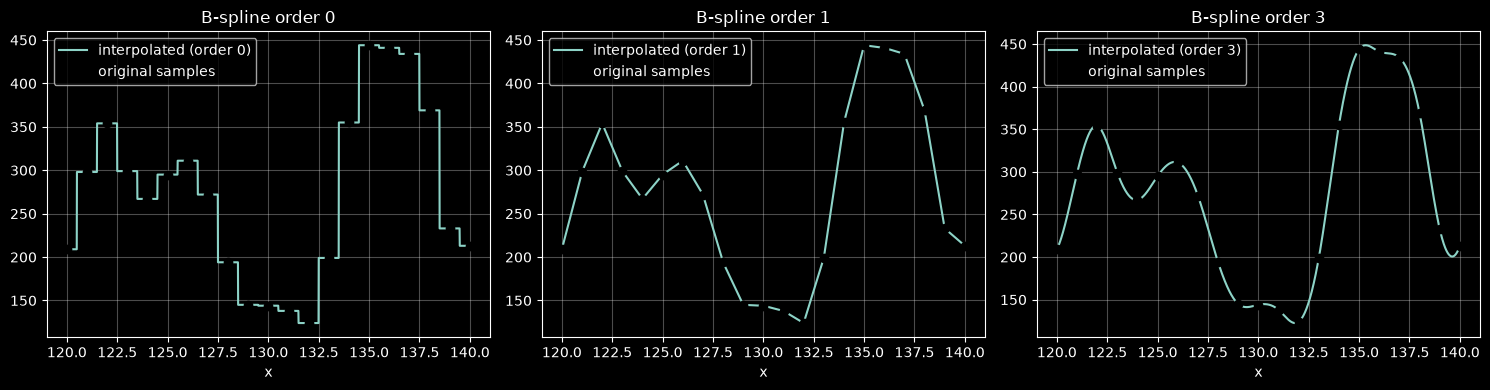

In [91]:
import numpy as np
import matplotlib.pyplot as plt

def interpolate_signal(t, N, order):
    # M = N basis functions, one centered at each integer location, h=1
    x_samples = np.arange(N)

    # Build the (square) NxN design matrix
    Phi = np.zeros((N, N))
    for m in range(N):
        Phi[:, m] = eval_BSpline(x_samples - m, order=order)

    # Solve Phi @ w = t directly (Phi is square -> exact interpolation, no need for normal equations)
    w = np.linalg.solve(Phi, t)

    return w

def evaluate_interpolation(w, x_eval, order):
    # y(x, w) = sum_m w_m * phi_m(x), evaluated at arbitrary (possibly non-integer) locations
    N = len(w)
    y = np.zeros_like(x_eval)
    for m in range(N):
        y += w[m] * eval_BSpline(x_eval - m, order=order)
    return y

# Fine evaluation grid
x_eval = np.arange(120, 140.01, 0.01)

# Corresponding original samples in that range, for comparison
mask = (x_samples_full := np.arange(N))
in_range = (x_samples_full >= 120) & (x_samples_full <= 140)

orders = [0, 1, 3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, order in zip(axes, orders):
    w = interpolate_signal(t, N, order)
    y = evaluate_interpolation(w, x_eval, order)

    ax.plot(x_eval, y, label=f"interpolated (order {order})")
    ax.plot(x_samples_full[in_range], t[in_range], 'o', label="original samples", color='black')
    ax.set_title(f"B-spline order {order}")
    ax.set_xlabel("x")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Task 4: Smoothing in 2D
Now you are going to smooth the 2D image $\mathbf{T}$, which has dimensions $N_1 \times N_2 = 256 \times 256$, with $M_1=M_2=5$ B-spline-based 1D basis functions of order 3 for each direction.

Use the Kronecker product to produce a $N \times M$ matrix $\boldsymbol{\Phi} = \boldsymbol{\Phi}_2 \otimes \boldsymbol{\Phi}_1$, where:
- $N=N_1 N_2$ 
- $M = M_1 M_2$. 

Show a few 2D basis functions contained in the columns of $\boldsymbol{\Phi}$.

>***Hints***:
>* the Kronecker product of two matrices A and B can be calculated with ```np.kron(A, B)```
>* for converting a vectorized basis function ```v``` back into its 2D shape, use ```v.reshape(N_1, N_2, order='F')```
>* the following snippet can be used to show a 2D basis function:
>    ```
>        plt.figure(); 
>        ax = plt.axes(projection='3d'); 
>        ax.plot_wireframe(np.arange(N1).reshape(-1, 1), np.arange(N2).reshape(1, -1), basisFunction)
>
>    ```

Phi shape: (65536, 25)


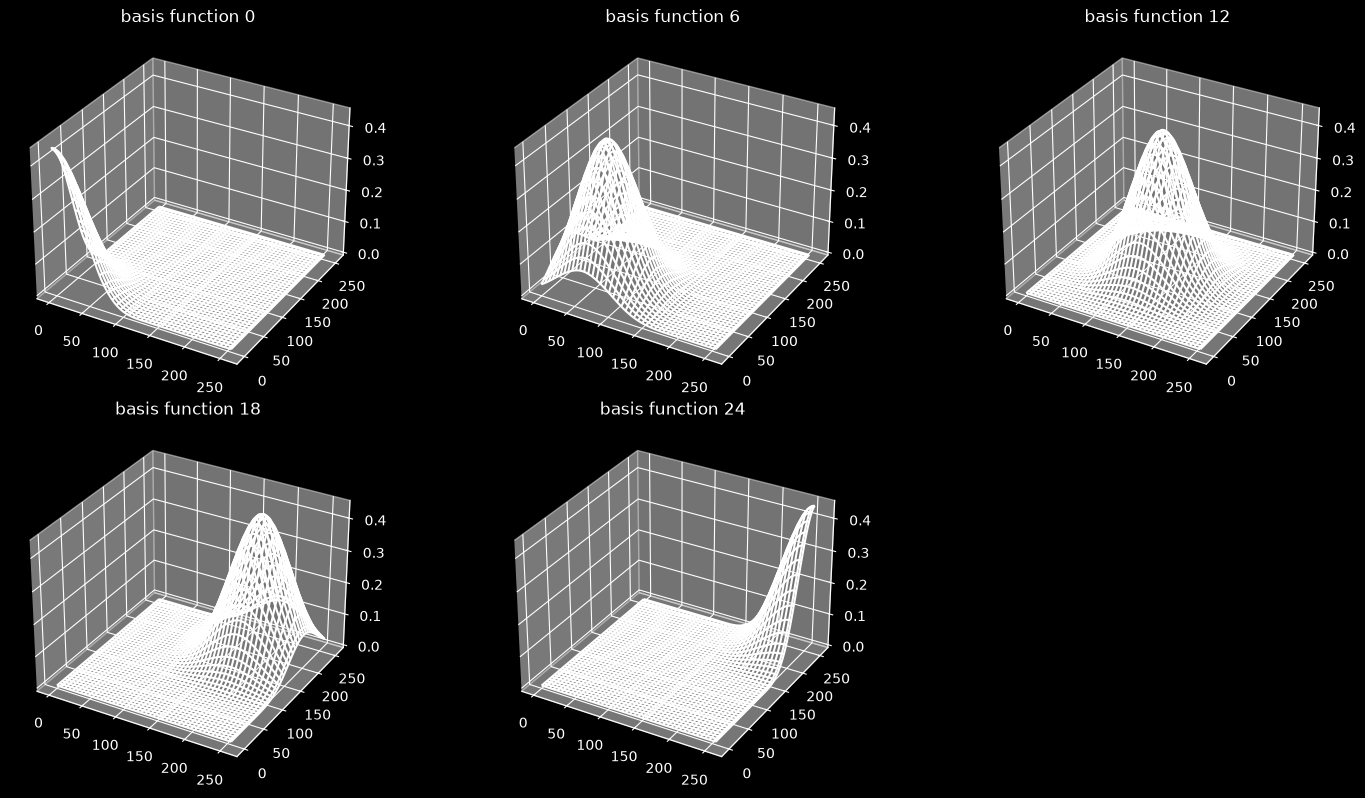

In [92]:
N1, N2 = 256, 256
M1, M2 = 5, 5

def build_Phi_1D(N, M, order=3):
    x = np.arange(N)
    h = (N - 1) / (M - 1)
    Phi = np.zeros((N, M))
    for m in range(M):
        center = m * h
        Phi[:, m] = eval_BSpline((x - center) / h, order=order)
    return Phi

# Build the two 1D basis matrices (one per image dimension)
Phi1 = build_Phi_1D(N1, M1, order=3)   # N1 x M1
Phi2 = build_Phi_1D(N2, M2, order=3)   # N2 x M2

# Combine via Kronecker product into the full 2D design matrix
Phi = np.kron(Phi2, Phi1)              # (N1*N2) x (M1*M2)
N = N1 * N2
M = M1 * M2
print("Phi shape:", Phi.shape)          # should be (65536, 25)

# Show a few 2D basis functions (columns of Phi)
cols_to_show = [0, 6, 12, 18, 24]   # a spread of basis functions, including the center one

fig = plt.figure(figsize=(15, 8))
for i, col in enumerate(cols_to_show):
    basisFunction = Phi[:, col].reshape(N1, N2, order='F')

    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    ax.plot_wireframe(
        np.arange(N1).reshape(-1, 1),
        np.arange(N2).reshape(1, -1),
        basisFunction
    )
    ax.set_title(f"basis function {col}")

plt.tight_layout()
plt.show()

Now:
- vectorize the 2D image $\mathbf{T}$ into a 1D signal $\mathbf{t}$
- smooth using $\boldsymbol{\Phi}$
- re-arrange the resulting 1D signal $\mathbf{\hat{t}}$ back into a 2D image $\mathbf{\hat{T}}$
- show the result.

>***Hints***: 
>* use ```T.reshape(-1, 1, order='F')``` and ```t.reshape(N_1, N_2, order='F')``` to vectorize and undo the vectorization.
>* do not explicitly compute the smoothing matrix $\mathbf{S}$ as it is very large!! Instead compute the weights $\mathbf{w} = (\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T \mathbf{t}$ and expand those to get $\mathbf{\hat{t}} = \boldsymbol{\Phi} \mathbf{w}$.


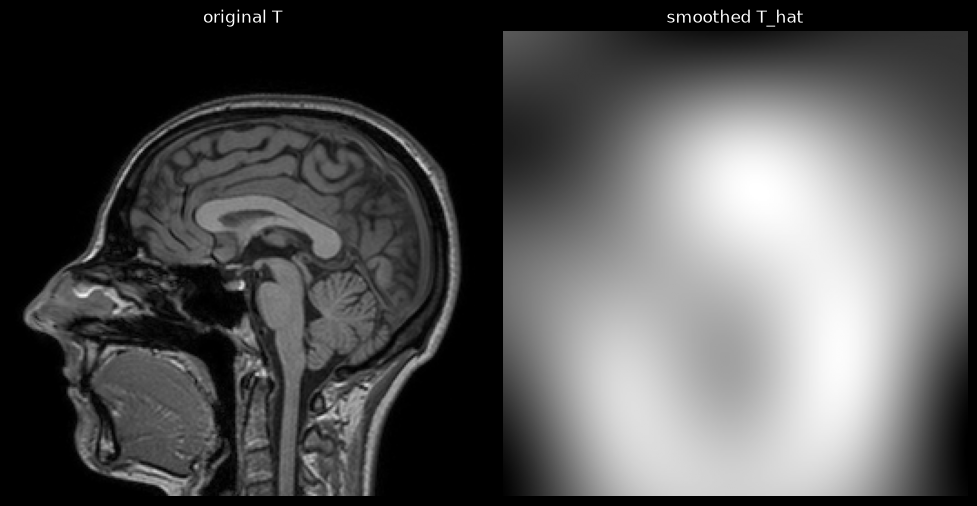

In [93]:
# Vectorize the 2D image T into a 1D signal t
t = T.reshape(-1, 1, order='F')   # (N1*N2, 1)

# Compute the weights w = (Phi^T Phi)^-1 Phi^T t, without forming S explicitly
PhiT = Phi.T
PhiT_Phi = PhiT @ Phi          # M x M  (small, e.g. 25x25 — cheap!)
PhiT_t = PhiT @ t              # M x 1

w = np.linalg.solve(PhiT_Phi, PhiT_t)   # M x 1

# Expand back to the full smoothed signal
t_hat = Phi @ w                 # N x 1

# Re-arrange back into a 2D image
T_hat = t_hat.reshape(N1, N2, order='F')

# Show the result
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(T, cmap='gray')
axes[0].set_title("original T")
axes[0].axis('off')

axes[1].imshow(T_hat, cmap='gray')
axes[1].set_title("smoothed T_hat")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Also perform the same smoothing operation by exploiting the separability of the 2D basis functions, i.e, perform row-wise and then column-wise smoothing instead. 

Show the results, and verify that they are identical (use ```np.allclose()```) 

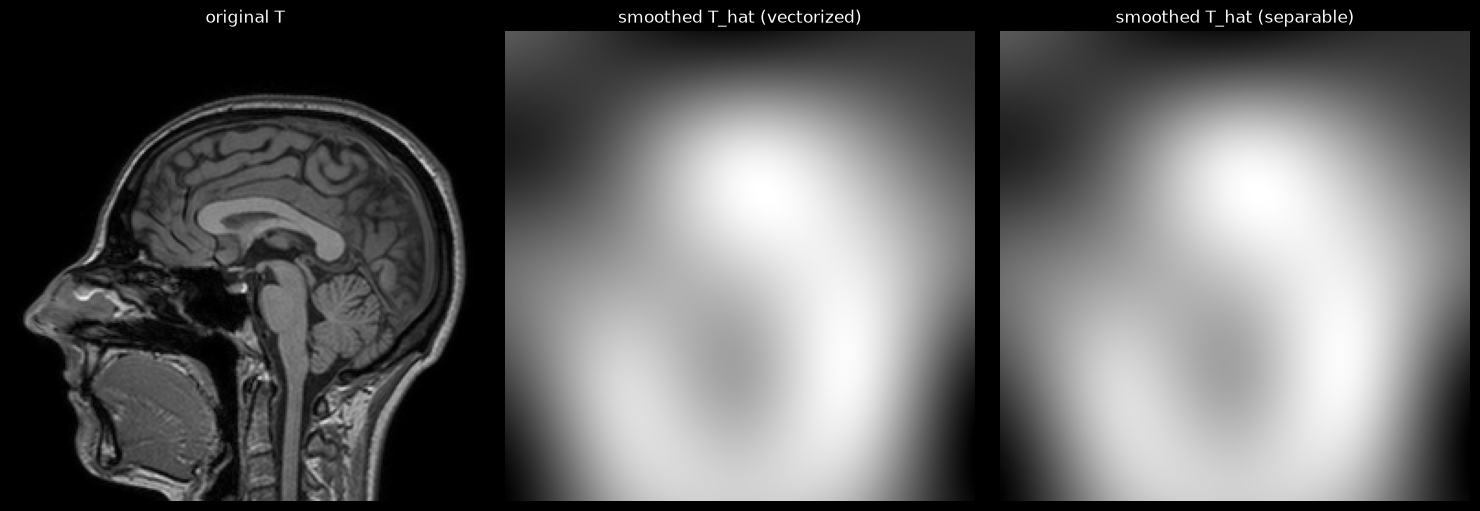

Identical results: True


In [94]:
import numpy as np
import matplotlib.pyplot as plt

# Separable smoothing: exploit Phi = kron(Phi2, Phi1)
# W = (Phi1^T Phi1)^-1 Phi1^T @ T @ Phi2 @ (Phi2^T Phi2)^-1

Phi1T_Phi1 = Phi1.T @ Phi1     # M1 x M1 (tiny: 5x5)
Phi2T_Phi2 = Phi2.T @ Phi2     # M2 x M2 (tiny: 5x5)

# Step 1: C = Phi1^T @ T @ Phi2   (compute the "coefficients" c = Phi^T t, efficiently)
C = Phi1.T @ T @ Phi2           # M1 x M2

# Step 2: solve for W using the two small matrices (avoids forming Phi^T Phi, which is MxM but fine here;
# the real saving is avoiding the NxN operations on T directly)
W = np.linalg.solve(Phi1T_Phi1, C)                    # solves Phi1T_Phi1 @ W = C for intermediate step
W = np.linalg.solve(Phi2T_Phi2, W.T).T                # then solve on the other side

# Step 3: expand back to full image
T_hat_separable = Phi1 @ W @ Phi2.T

# Show the result
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(T, cmap='gray')
axes[0].set_title("original T")
axes[0].axis('off')

axes[1].imshow(T_hat, cmap='gray')
axes[1].set_title("smoothed T_hat (vectorized)")
axes[1].axis('off')

axes[2].imshow(T_hat_separable, cmap='gray')
axes[2].set_title("smoothed T_hat (separable)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Verify the two approaches give identical results
print("Identical results:", np.allclose(T_hat, T_hat_separable))

---
## Task 5: Interpolation in 2D
For B-spline order 0, 1 and 3, compute the weights $\mathbf{W}$ of the 2D interpolation model fitted to $\mathbf{T}$ by exploiting the separability of its basis functions.

Then show, as an image, interpolated function values $y( \mathbf{x}, \mathbf{w})$ for $\mathbf{x}=(x_1, x_2)^T$ with:
- $x_1=120.0, 120.1, 120.2 \ldots, 130.0$ 
- $x_2=120.0, 120.1, 120.2 \ldots, 130.0$ 